# Visualize `responses.json`: worlds, paths, and behavior trees

Loads each model’s stored LLM outputs from `src/tasks/responses.json`, joins them with `src/tasks/tasks.json` for obstacles and targets, runs the simulator with path recording, and plots:

- Obstacles (gray), targets (green), robot path (blue), start/end markers
- The parsed behavior tree as a directed graph (same layout style as `visualize_bt.ipynb`)

Run this notebook from the repo root or from `notebooks/`; the first code cell adds the project root to `sys.path`.

In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.parsers.bt import parse_bt_output
from src.simulator import INITIAL_SPOT_STATE, simulate_bt_plan

TASKS_PATH = PROJECT_ROOT / "src" / "tasks" / "tasks_100.json"
RESPONSES_PATH = PROJECT_ROOT / "src" / "tasks" / "ground_truth_responses.json"

tasks = json.loads(TASKS_PATH.read_text(encoding="utf-8"))
responses = json.loads(RESPONSES_PATH.read_text(encoding="utf-8"))
task_by_id = {t["task_id"]: t for t in tasks}

print(f"Tasks: {len(tasks)} | Models in responses: {list(responses.keys())}")

Tasks: 5 | Models in responses: ['Qwen2.5-3B-Instruct', 'GPT-5.4-Thinking']


In [8]:
def _strip_json_fences(text: str) -> str:
    text = (text or "").strip()
    if text.startswith("```"):
        lines = text.splitlines()
        if lines and lines[0].strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]
        text = "\n".join(lines).strip()
    return text


def _node_label(node: dict) -> str:
    node_type = node.get("type", "?")
    if node_type == "condition":
        observation = node.get("observation", "?")
        expected = node.get("expected", True)
        return f"condition\n{observation} == {expected}"
    if node_type == "action":
        call = node.get("call", {})
        tool_name = call.get("tool_name", "?")
        args = call.get("arguments", {})
        if args:
            args_text = "\n".join(f"{k}={v}" for k, v in args.items())
            return f"action\n{tool_name}\n{args_text}"
        return f"action\n{tool_name}"
    return node_type


def _add_bt_nodes(graph: nx.DiGraph, node: dict, parent_id: str | None = None, idx: list[int] | None = None) -> None:
    if idx is None:
        idx = [0]
    node_id = f"n{idx[0]}"
    idx[0] += 1
    graph.add_node(node_id, label=_node_label(node))
    if parent_id is not None:
        graph.add_edge(parent_id, node_id)
    for child in node.get("children", []):
        _add_bt_nodes(graph, child, parent_id=node_id, idx=idx)


def _tree_layout_top_down(graph: nx.DiGraph, root: str) -> dict[str, tuple[float, float]]:
    levels: dict[int, list[str]] = {}

    def _walk(node_id: str, depth: int) -> None:
        levels.setdefault(depth, []).append(node_id)
        for child_id in graph.successors(node_id):
            _walk(child_id, depth + 1)

    _walk(root, 0)
    pos: dict[str, tuple[float, float]] = {}
    for depth, nodes in levels.items():
        width = len(nodes)
        for i, node_id in enumerate(nodes):
            x = (i + 1) / (width + 1)
            y = -(depth * 1.5)
            pos[node_id] = (x, y)
    return pos


def render_behavior_tree(bt_payload: dict, title: str = "Behavior Tree") -> None:
    graph = nx.DiGraph()
    root = bt_payload.get("root")
    if not isinstance(root, dict):
        raise ValueError("BT payload must contain a dict root node")
    _add_bt_nodes(graph, root)
    labels = nx.get_node_attributes(graph, "label")
    root_node = "n0"
    pos = _tree_layout_top_down(graph, root_node)
    plt.figure(figsize=(14, 9))
    nx.draw(
        graph,
        pos,
        with_labels=False,
        arrows=True,
        node_size=5000,
        node_color="#DDEEFF",
        edge_color="#666666",
    )
    nx.draw_networkx_labels(
        graph,
        pos,
        labels=labels,
        font_size=11,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 0.3},
    )
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_world_and_path(
    obstacles: list[dict],
    targets: list[dict],
    path: list[dict[str, float]],
    *,
    title: str,
    heading_arrow_every: int = 1,
    arrow_len: float = 0.35,
) -> None:
    fig, ax = plt.subplots(figsize=(10, 8))
    for ob in obstacles:
        w, h = ob["x2"] - ob["x1"], ob["y2"] - ob["y1"]
        ax.add_patch(
            mpatches.Rectangle(
                (ob["x1"], ob["y1"]),
                w,
                h,
                facecolor="#BBBBBB",
                edgecolor="#333333",
                linewidth=1.2,
                alpha=0.85,
            )
        )
    for tg in targets:
        w, h = tg["x2"] - tg["x1"], tg["y2"] - tg["y1"]
        ax.add_patch(
            mpatches.Rectangle(
                (tg["x1"], tg["y1"]),
                w,
                h,
                facecolor="#A8E6A3",
                edgecolor="#1B5E20",
                linewidth=1.5,
                alpha=0.55,
            )
        )
    if path:
        xs = [p["x"] for p in path]
        ys = [p["y"] for p in path]
        ax.plot(xs, ys, "b-", linewidth=2.0, label="path", zorder=3)
        ax.scatter([xs[0]], [ys[0]], c="#0066CC", s=80, zorder=4, label="start")
        ax.scatter([xs[-1]], [ys[-1]], c="#CC3300", s=100, marker="*", zorder=4, label="end")

        # Draw heading arrows only for translation samples (skip in-place rotations)
        # and always include the final orientation at the end point.
        heading_samples: list[tuple[int, dict[str, float]]] = []
        for i, p in enumerate(path):
            if i == 0:
                heading_samples.append((i, p))
                continue
            prev = path[i - 1]
            moved = (abs(p["x"] - prev["x"]) > 1e-9) or (abs(p["y"] - prev["y"]) > 1e-9)
            if moved:
                heading_samples.append((i, p))

        if heading_samples and heading_samples[-1][0] != len(path) - 1:
            heading_samples.append((len(path) - 1, path[-1]))

        for sample_i, p in heading_samples:
            if heading_arrow_every > 0 and sample_i % heading_arrow_every != 0 and sample_i != len(path) - 1:
                continue
            th = np.radians(p["heading"])
            dx, dy = arrow_len * np.cos(th), arrow_len * np.sin(th)
            ax.arrow(
                p["x"],
                p["y"],
                dx,
                dy,
                head_width=0.12,
                head_length=0.12,
                fc="#004499",
                ec="#004499",
                length_includes_head=True,
                zorder=5,
            )
    ax.scatter(
        [INITIAL_SPOT_STATE["x"]],
        [INITIAL_SPOT_STATE["y"]],
        c="none",
        edgecolors="#000000",
        s=120,
        linewidths=2,
        label="initial (reference)",
        zorder=4,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

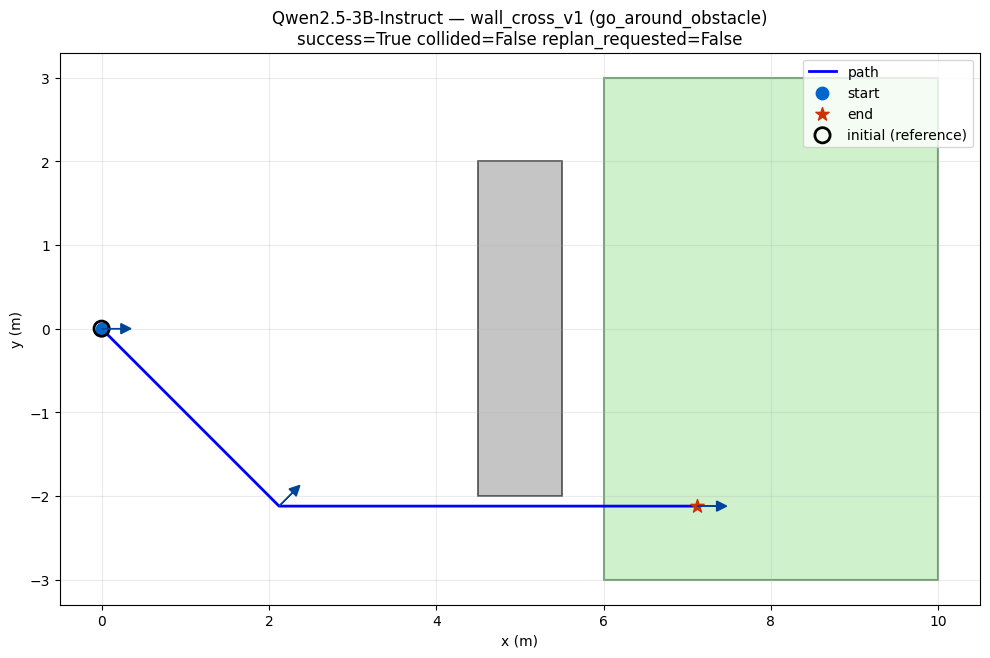

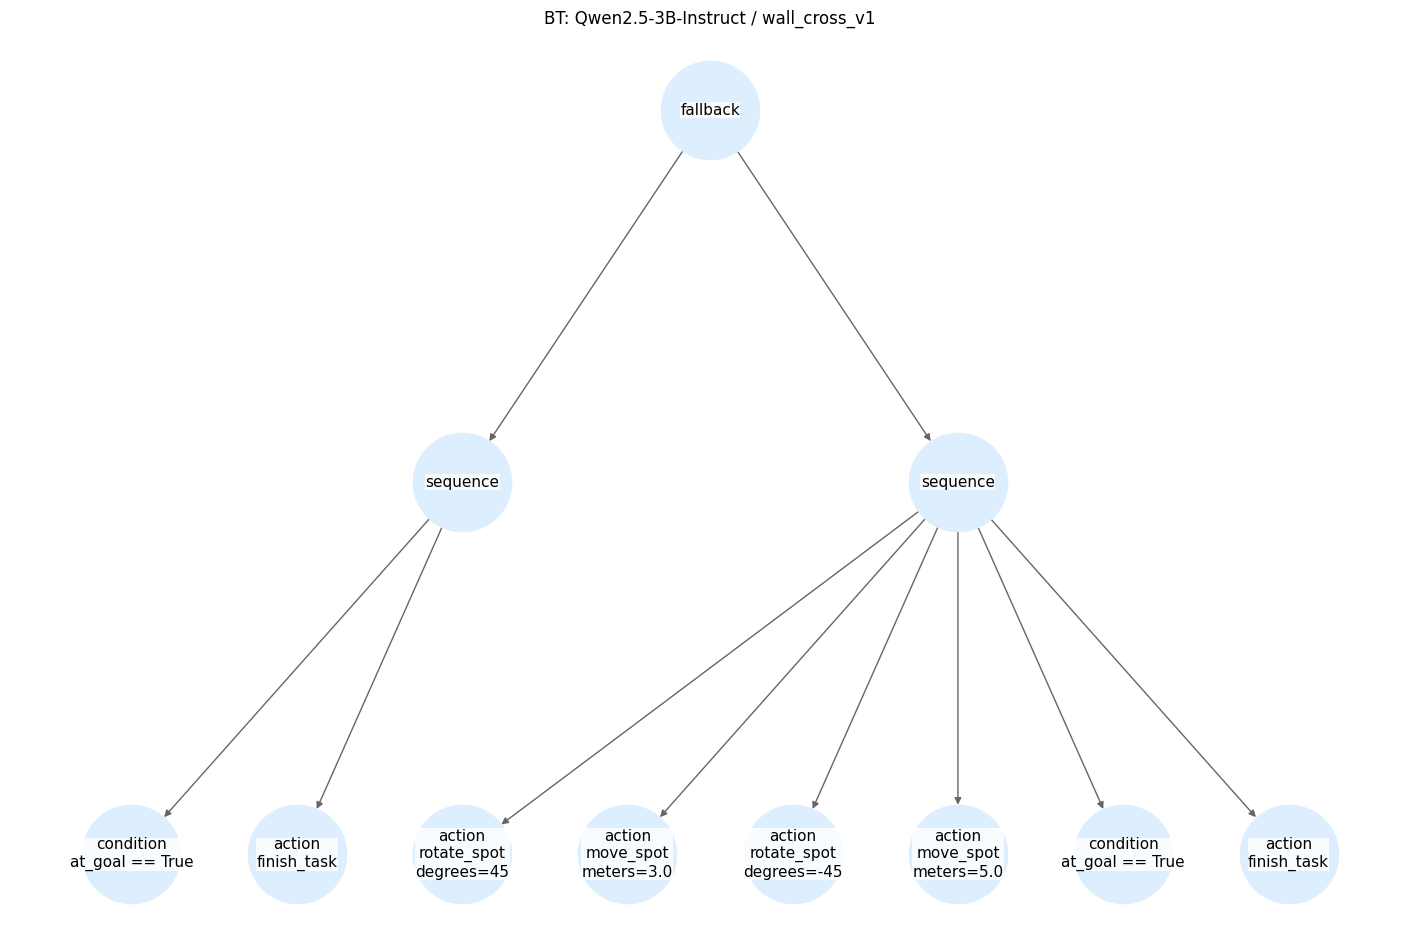

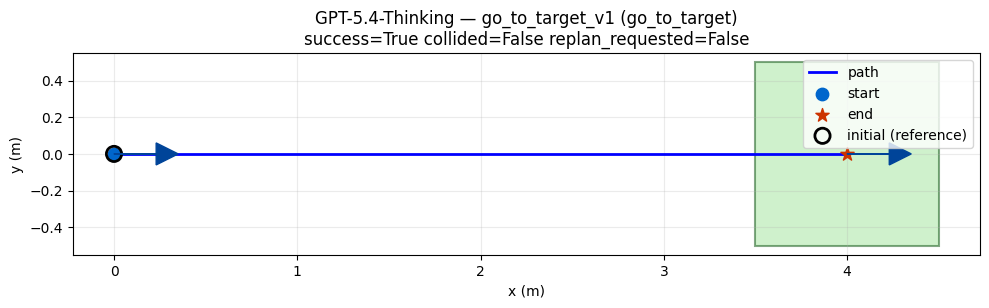

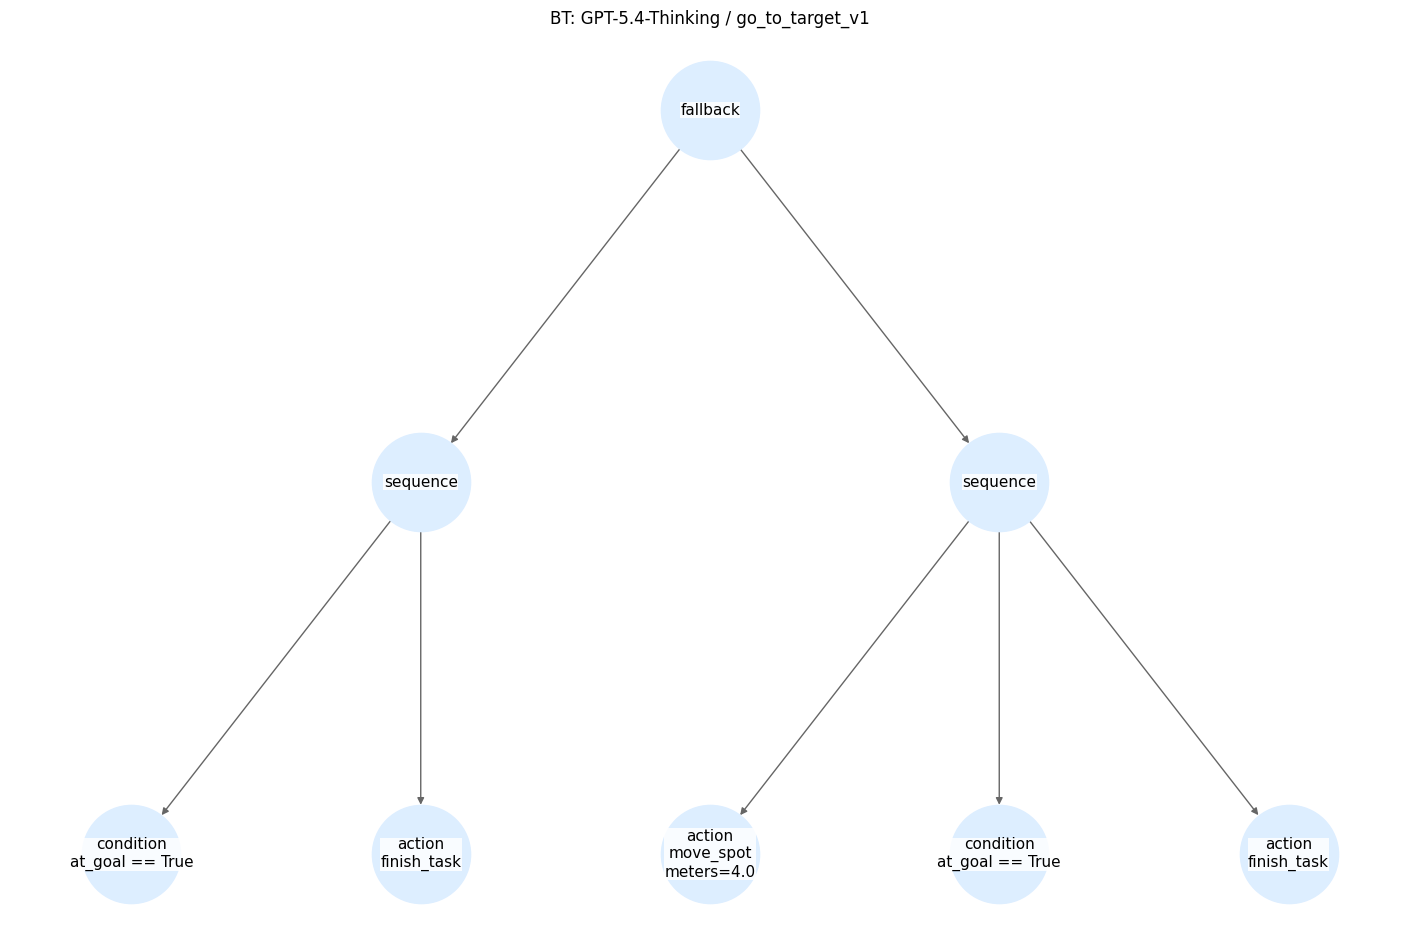

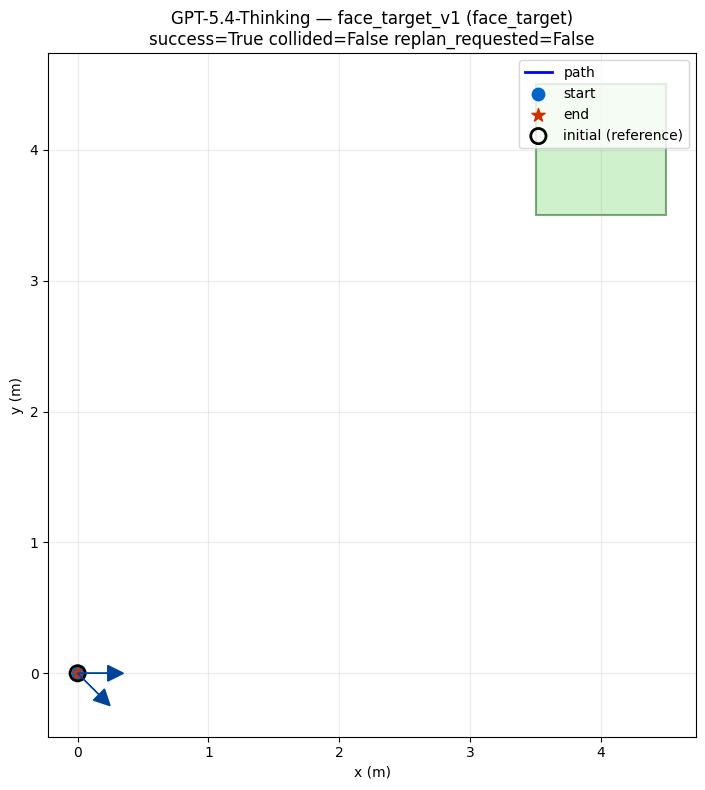

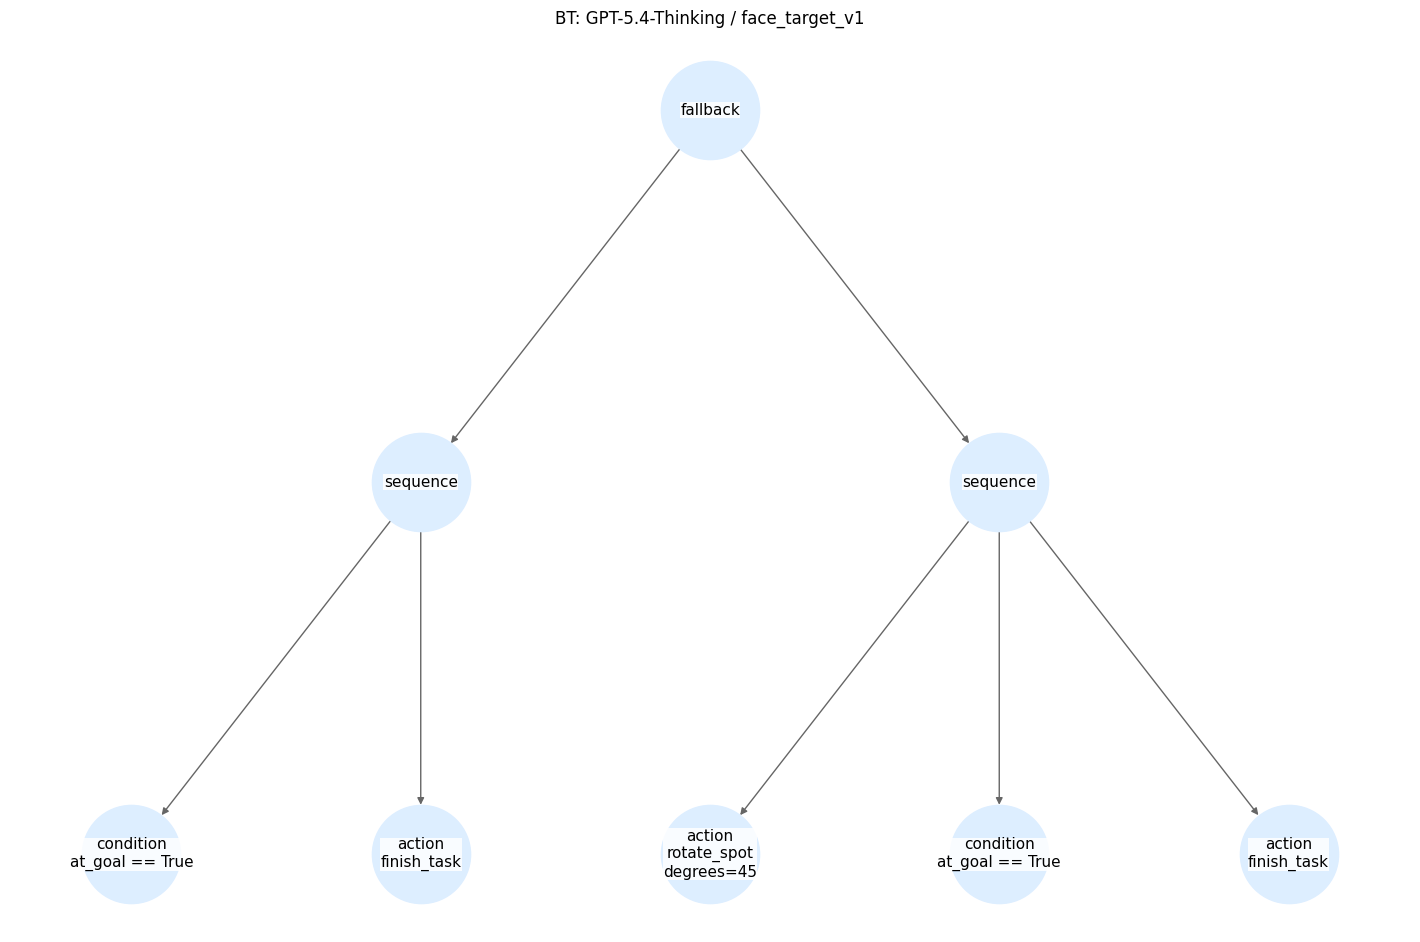

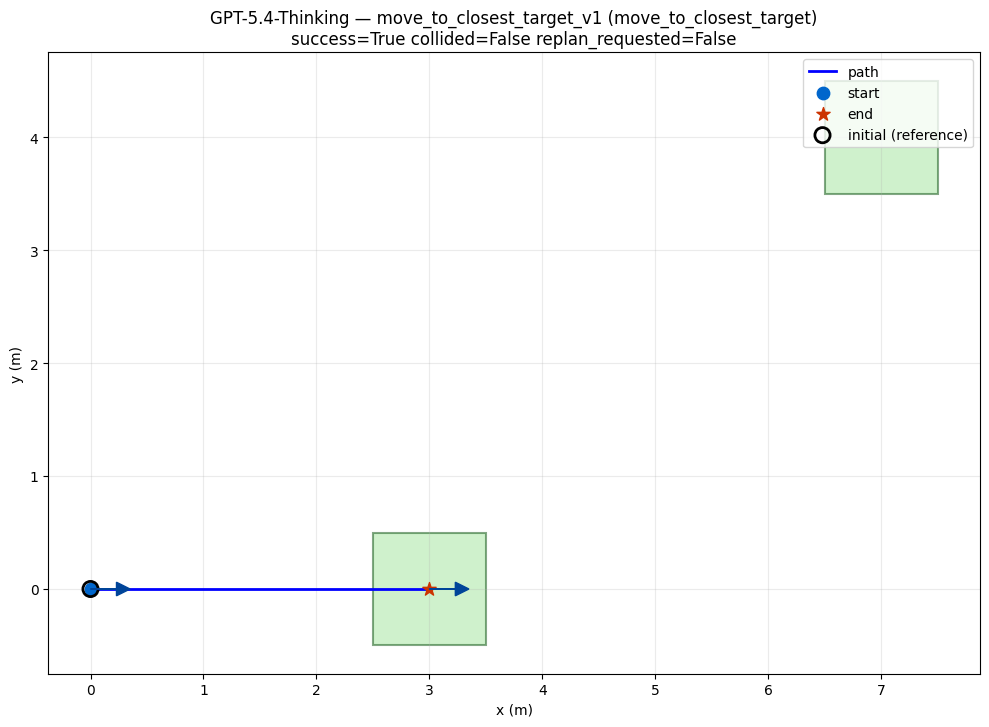

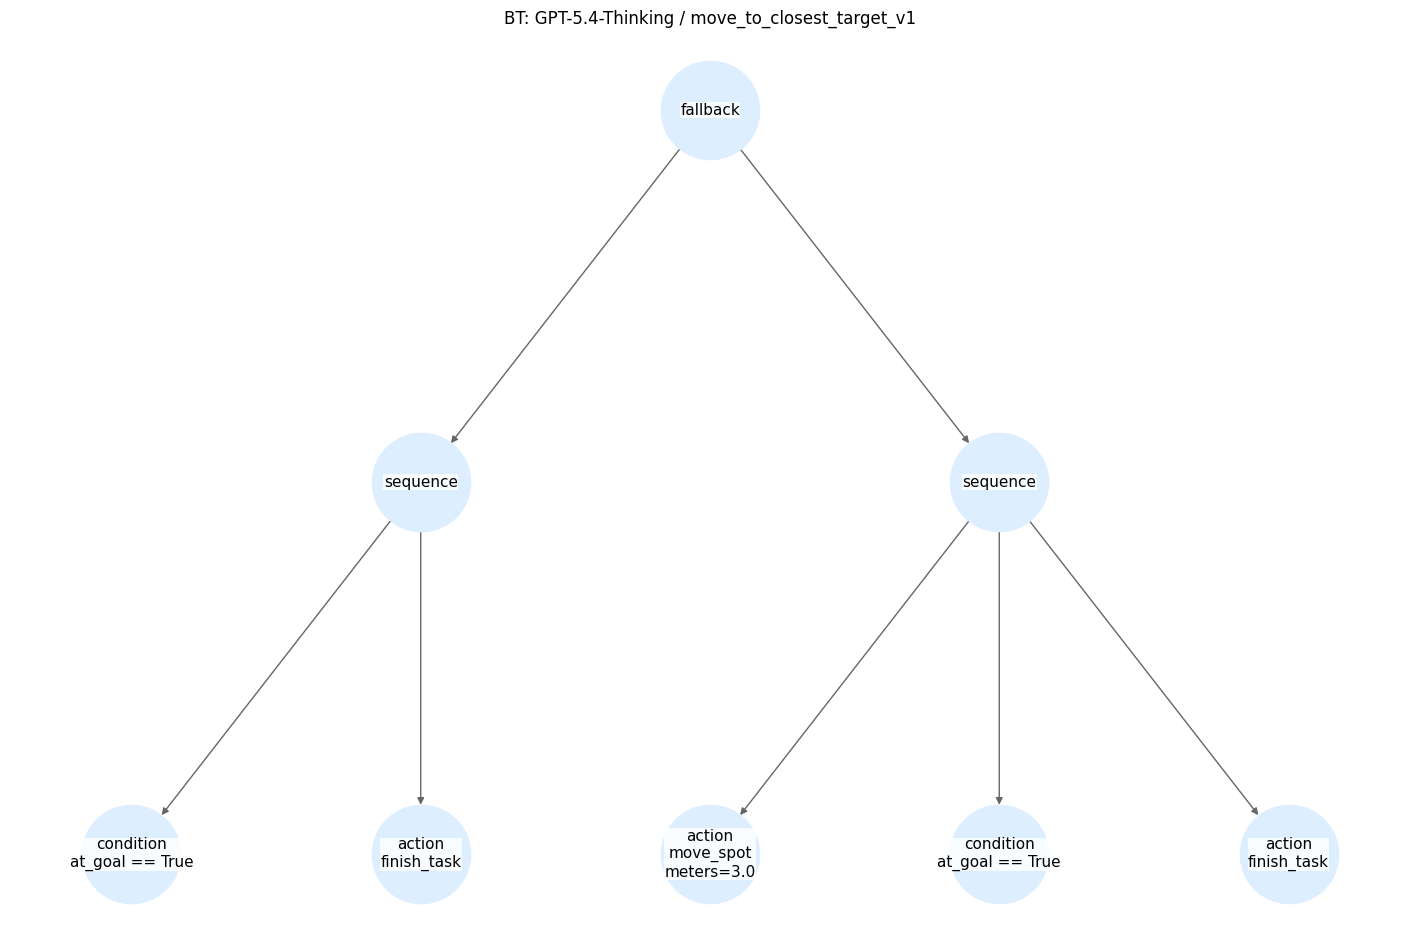

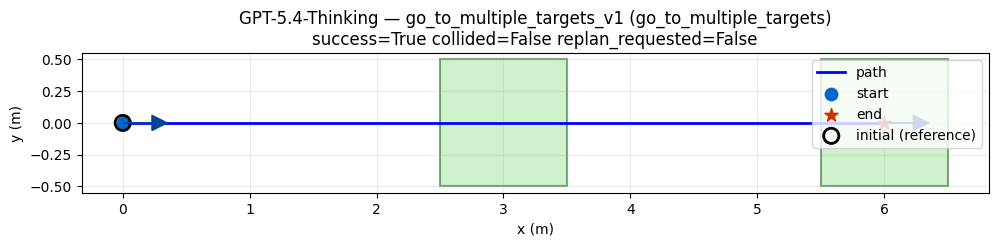

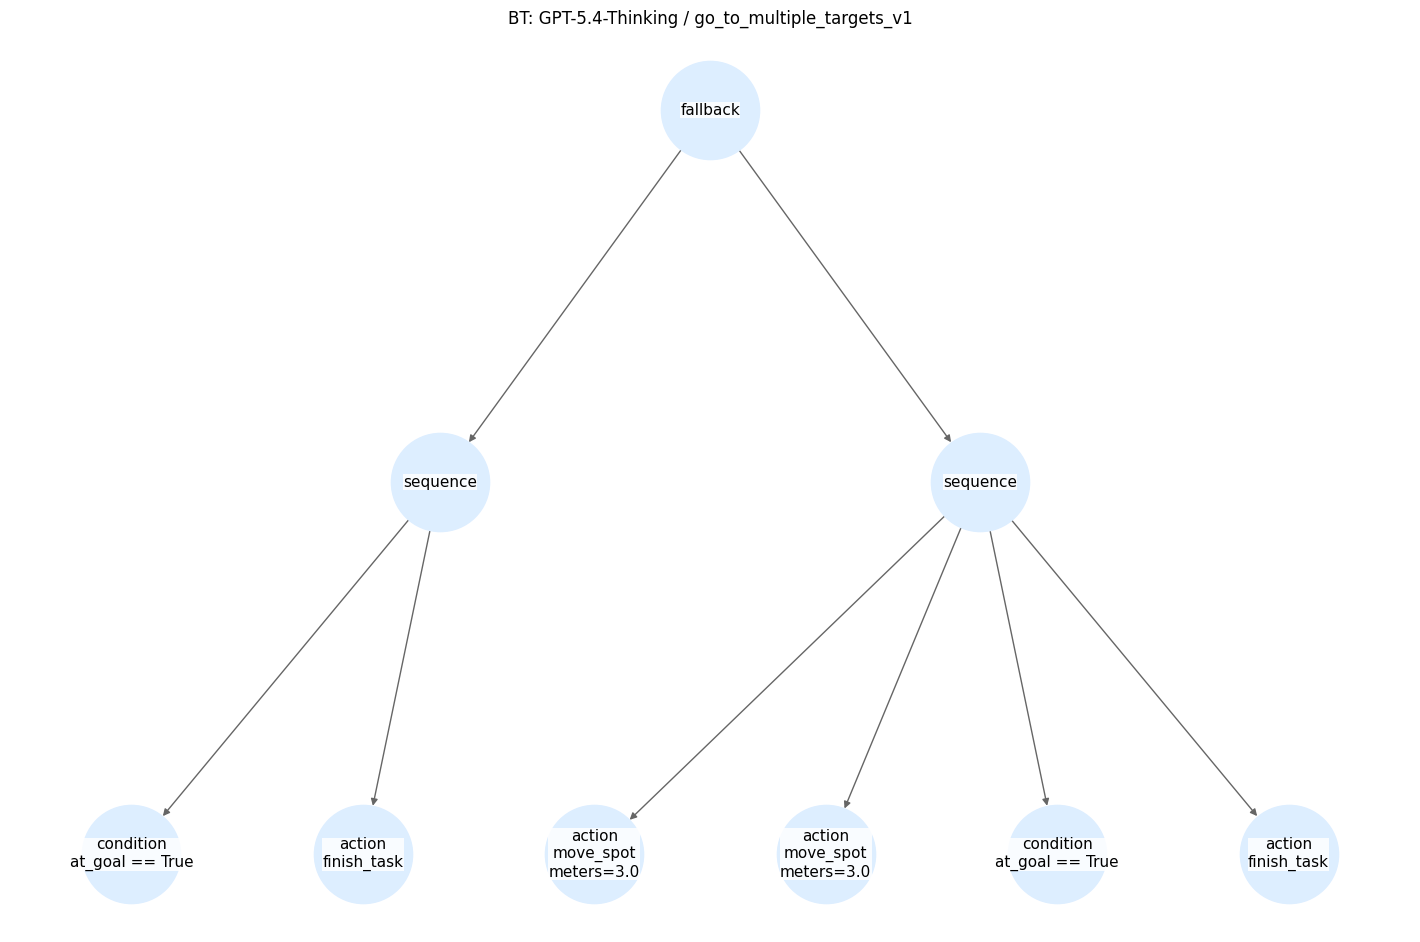

In [9]:
for model_id, entries in responses.items():
    for entry in entries:
        task_id = entry["task_id"]
        raw = entry.get("llm_output", "")
        task = task_by_id.get(task_id)
        if task is None:
            print(f"[skip] {model_id} / {task_id}: no matching task in tasks.json")
            continue

        task_env = {**task["world"], "task_type": task["task_type"]}
        plan, err = parse_bt_output(raw)
        if err is not None:
            print(f"[parse error] {model_id} / {task_id}: {err}")
            continue

        result = simulate_bt_plan(plan, task_env=task_env, record_path=True)
        path = result.get("path", [])
        success = bool(result.get("success"))
        collided = bool(result.get("collided"))

        world_title = (
            f"{model_id} — {task_id} ({task['task_type']})\n"
            f"success={success} collided={collided} replan_requested={result.get('replan_requested')}"
        )
        plot_world_and_path(
            task_env["obstacles"],
            task_env["targets"],
            path,
            title=world_title,
            heading_arrow_every=2,
        )

        try:
            bt_payload = json.loads(_strip_json_fences(raw))
            render_behavior_tree(bt_payload, title=f"BT: {model_id} / {task_id}")
        except Exception as ex:
            print(f"[bt graph skip] {model_id} / {task_id}: {ex}")